# 📦 S3 Object Staleness Predictor — With Savings & Priority Groups

**Objective:** Predict whether an S3 object is stale AND rank it by **business value of deletion** so teams can act on the highest-savings objects first.

**Dataset:** `data/inventory_updated.csv` — 92,369 records, 10 columns.

**Target:** `is_stale` (Boolean — 1 = Stale, 0 = Active)

**Enhancement:** Each predicted-stale object is assigned a **Priority Group** (Critical / High / Medium / Low) based on estimated storage cost savings, staleness confidence, and object age. This transforms raw predictions into an actionable remediation queue.

---
## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Load & Inspect Data](#2-load--inspect-data)
3. [Data Cleaning](#3-data-cleaning)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Outlier Analysis](#5-outlier-analysis)
6. [Feature Engineering](#6-feature-engineering)
7. [Preprocessing & Class Imbalance](#7-preprocessing--class-imbalance)
8. [Baseline Model — Logistic Regression](#8-baseline-model--logistic-regression)
9. [Improved Model — Random Forest](#9-improved-model--random-forest)
10. [Model Evaluation & Comparison](#10-model-evaluation--comparison)
11. [Feature Importance](#11-feature-importance)
12. [Savings Estimation & Priority Groups](#12-savings-estimation--priority-groups)
13. [Priority Group Visualisations](#13-priority-group-visualisations)
14. [Predict & Triage New Objects](#14-predict--triage-new-objects)
15. [Conclusion](#15-conclusion)

---
## 1. Setup & Imports

In [3]:
# ── Standard library ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Scikit-learn ───────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, f1_score
)

# ── Class imbalance ────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Global plot settings ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

RANDOM_STATE = 42
DATA_PATH    = 'data/inventory_updated.csv'

# ── S3 pricing constants (USD) ─────────────────────────────────────────────────
# Standard storage cost per GB per month (AWS S3 Standard, us-east-1)
S3_COST_PER_GB_MONTH = 0.023
# Months to project savings over (1-year horizon)
SAVINGS_HORIZON_MONTHS = 12

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


---
## 2. Load & Inspect Data

In [4]:
# Load CSV — parse both date columns at read time
df = pd.read_csv(
    DATA_PATH,
    parse_dates=['last Modified', 'last accessed column'],
    low_memory=False
)

# Normalise column names: strip, lowercase, underscores
df.columns = (
    df.columns.str.strip().str.lower()
    .str.replace(' ', '_', regex=False)
)
df = df.rename(columns={'last_accessed_column': 'last_accessed'})

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\nColumn dtypes:')
print(df.dtypes)
df.head(3)

Shape: 10,912 rows × 10 columns

Column dtypes:
bucket                          object
key                             object
version_id                      object
is_latest                       object
delete_marker                   object
size                           float64
last_modified      datetime64[ns, UTC]
encryption_type                 object
is_stale                        object
last_accessed           datetime64[ns]
dtype: object


,bucket,key,version_id,is_latest,delete_marker,size,last_modified,encryption_type,is_stale,last_accessed
0,stale-testing,acna/acna3/01/cq_backup/pacna10aem02/2018_01_0...,Dhyw0TsscD_kFhgAHDm02ZnDIsM.I7YP,True,False,456446938.0,2022-10-28 18:22:45+00:00,NOT-SSE,True,2024-08-27 20:06:58
1,stale-testing,acna/acna3/01/cq_backup/pacna10aem02/2018_01_0...,q3eu_1XR6ebFWqXoGrX6Px.dgtFD5ak3,True,False,456446938.0,2022-10-28 19:17:13+00:00,NOT-SSE,False,2025-08-16 08:42:27
2,stale-testing,acna/acna3/01/cq_backup/pacna10aem02/2018_01_1...,wsVWDq3Vi56Lg2m7PW1.AW73j.kwVyQ9,True,False,456446938.0,2022-10-28 19:48:57+00:00,NOT-SSE,False,2025-12-27 01:01:08


In [5]:
# Missing values and cardinality summary
summary = pd.DataFrame({
    'dtype':     df.dtypes,
    'missing':   df.isna().sum(),
    'missing_%': (df.isna().mean() * 100).round(2),
    'unique':    df.nunique()
})
print(summary.to_string())

                               dtype  missing  missing_%  unique
bucket                        object        0       0.00       1
key                           object        0       0.00   10912
version_id                    object        1       0.01   10911
is_latest                     object        1       0.01       1
delete_marker                 object        1       0.01       1
size                         float64        1       0.01     259
last_modified    datetime64[ns, UTC]        1       0.01    7221
encryption_type               object        1       0.01       2
is_stale                      object        1       0.01       2
last_accessed         datetime64[ns]        1       0.01   10907


In [6]:
# Target class balance
counts = df['is_stale'].value_counts()
pct    = df['is_stale'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': counts, '%': pct.round(2)}))

          count     %
is_stale             
True       5739  52.6
False      5172  47.4


---
## 3. Data Cleaning
Steps: remove duplicates → drop missing targets → impute categoricals → fix invalid sizes → flag & fill missing access dates → cast booleans.

In [7]:
# ── Duplicates ─────────────────────────────────────────────────────────────────
n_before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {n_before - len(df):,} | Remaining: {len(df):,}')

# ── Drop rows with no label ────────────────────────────────────────────────────
df = df.dropna(subset=['is_stale'])

# ── Categorical imputation ─────────────────────────────────────────────────────
df['version_id']      = df['version_id'].fillna('none')
df['encryption_type'] = df['encryption_type'].fillna('NONE')

# ── Fix invalid sizes ──────────────────────────────────────────────────────────
df.loc[df['size'] <= 0, 'size'] = np.nan
df['size'] = df['size'].fillna(df['size'].median())

# ── Drop rows with no modification date ───────────────────────────────────────
df = df.dropna(subset=['last_modified'])

# ── Flag and fill missing last_accessed ───────────────────────────────────────
# never_accessed is itself a strong staleness signal
df['never_accessed'] = df['last_accessed'].isna().astype(int)
df['last_accessed']  = df['last_accessed'].fillna(df['last_modified'])

# ── Cast booleans to int ───────────────────────────────────────────────────────
for col in ['is_latest', 'delete_marker', 'is_stale']:
    df[col] = df[col].astype(int)

print(f'Clean shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Remaining nulls: {df.isna().sum().sum()}')

Duplicates removed: 0 | Remaining: 10,912
Clean shape: 10,911 rows × 11 columns
Remaining nulls: 0


---
## 4. Exploratory Data Analysis

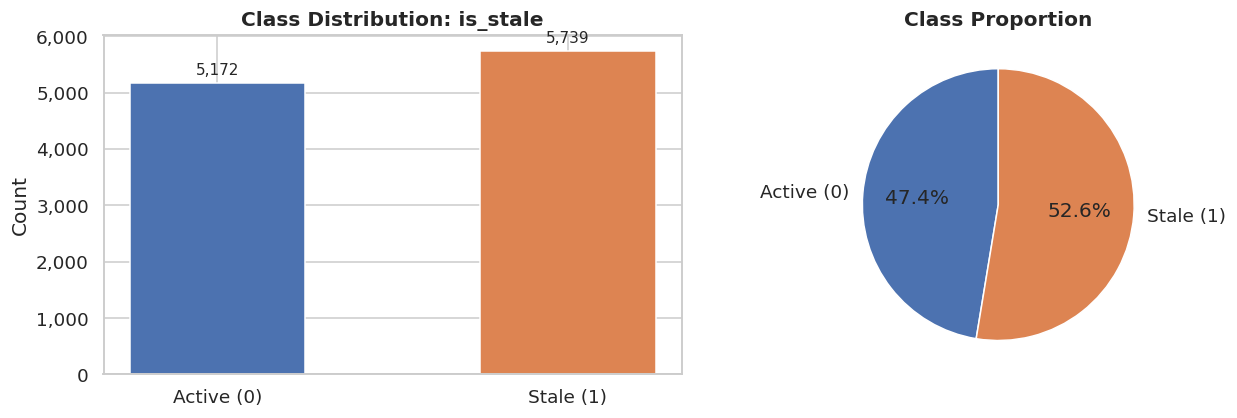

In [8]:
# ── Class balance ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Active (0)', 'Stale (1)']
cnts   = df['is_stale'].value_counts().sort_index().values
colors = ['#4C72B0', '#DD8452']

axes[0].bar(labels, cnts, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution: is_stale', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(cnts):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(cnts, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Proportion', fontweight='bold')
plt.tight_layout()
plt.show()

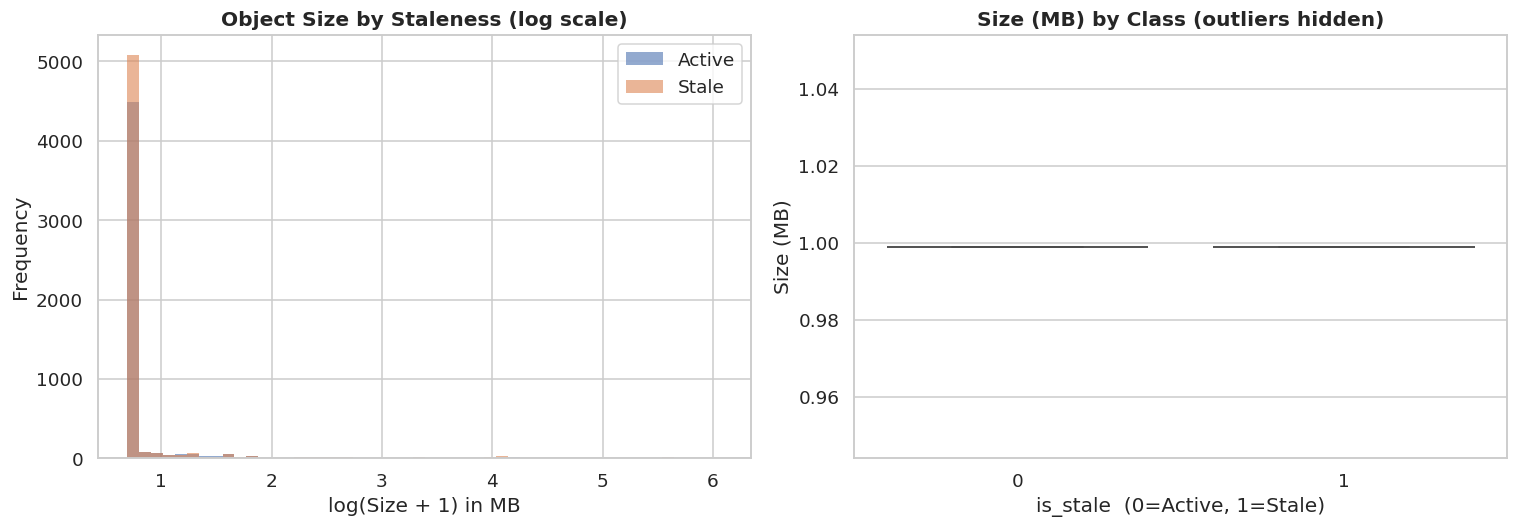

In [9]:
# ── Size distribution by staleness ────────────────────────────────────────────
df['size_mb'] = df['size'] / (1024 ** 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for val, lbl, col in [(0, 'Active', '#4C72B0'), (1, 'Stale', '#DD8452')]:
    axes[0].hist(np.log1p(df.loc[df['is_stale'] == val, 'size_mb']),
                 bins=50, alpha=0.6, label=lbl, color=col, edgecolor='none')
axes[0].set_title('Object Size by Staleness (log scale)', fontweight='bold')
axes[0].set_xlabel('log(Size + 1) in MB')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(data=df, x='is_stale', y='size_mb',
            palette={'0': '#4C72B0', '1': '#DD8452'},
            showfliers=False, ax=axes[1])
axes[1].set_title('Size (MB) by Class (outliers hidden)', fontweight='bold')
axes[1].set_xlabel('is_stale  (0=Active, 1=Stale)')
axes[1].set_ylabel('Size (MB)')
plt.tight_layout()
plt.show()

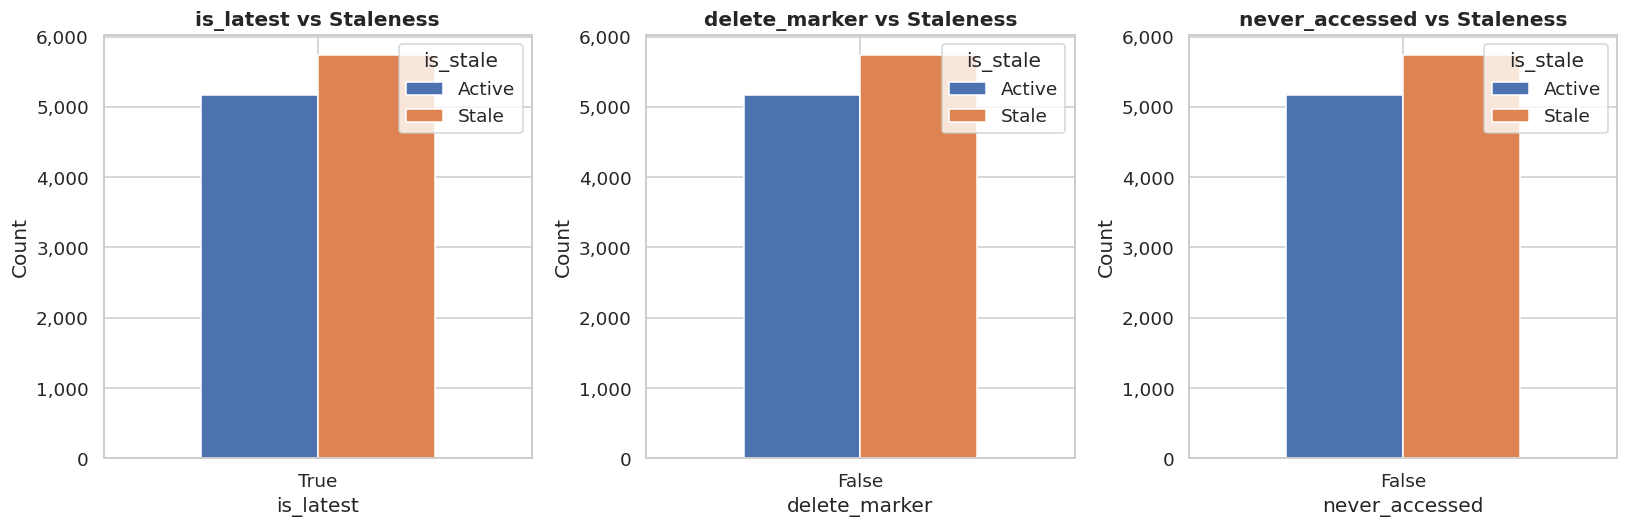

In [10]:
# ── Boolean features vs staleness ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['is_latest', 'delete_marker', 'never_accessed']):
    ct = df.groupby([col, 'is_stale']).size().unstack(fill_value=0)
    ct.index   = ct.index.map({0: 'False', 1: 'True'})
    ct.columns = ['Active', 'Stale']
    ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'],
            edgecolor='white', width=0.6, rot=0)
    ax.set_title(f'{col} vs Staleness', fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(title='is_stale')
plt.tight_layout()
plt.show()

In [11]:
# ── Encryption type vs staleness — interactive Plotly ─────────────────────────
enc_df = (
    df.groupby(['encryption_type', 'is_stale']).size()
    .reset_index(name='count')
)
enc_df['is_stale'] = enc_df['is_stale'].map({0: 'Active', 1: 'Stale'})
fig = px.bar(
    enc_df, x='encryption_type', y='count', color='is_stale', barmode='group',
    color_discrete_map={'Active': '#4C72B0', 'Stale': '#DD8452'},
    title='Encryption Type vs Staleness',
    labels={'encryption_type': 'Encryption Type', 'count': 'Count', 'is_stale': 'Status'}
)
fig.update_layout(xaxis_tickangle=-30, plot_bgcolor='white')
fig.show()

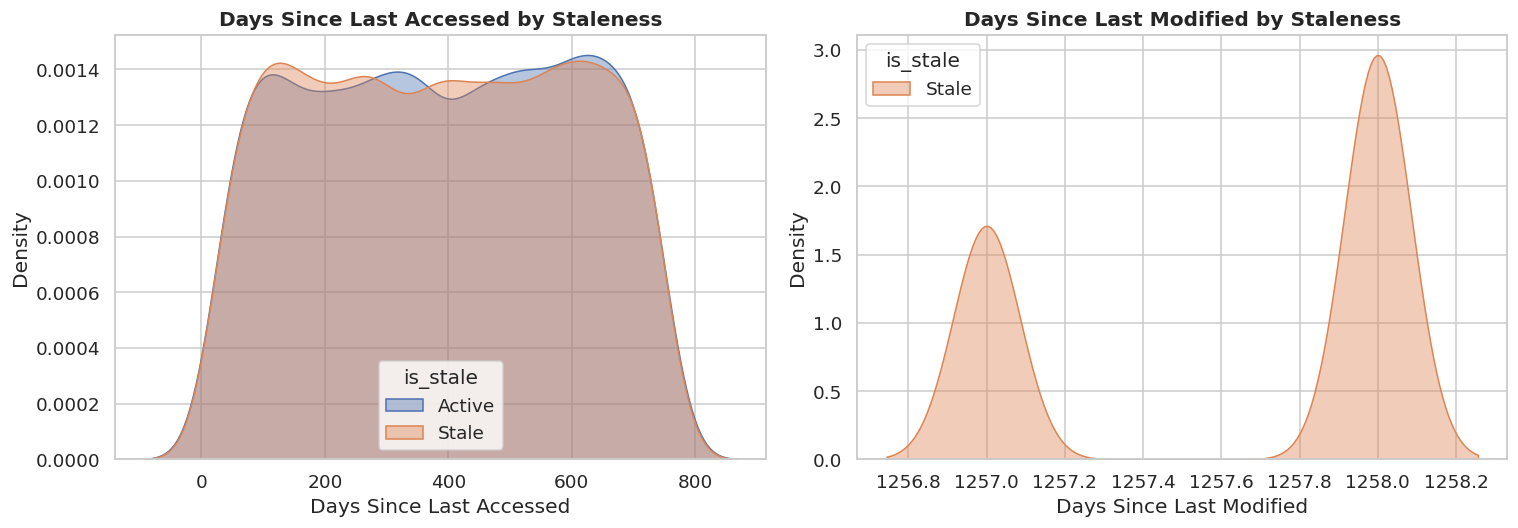

In [12]:
# ── Temporal patterns: days since accessed vs modified ────────────────────────
tmp = df[['last_modified', 'last_accessed', 'is_stale']].copy()
for c in ['last_modified', 'last_accessed']:
    if tmp[c].dt.tz is None:
        tmp[c] = tmp[c].dt.tz_localize('UTC')

ref_date = pd.Timestamp.now(tz='UTC').normalize()
tmp['days_since_modified'] = (ref_date - tmp['last_modified']).dt.days
tmp['days_since_accessed'] = (ref_date - tmp['last_accessed']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ['days_since_accessed', 'days_since_modified'],
    ['Days Since Last Accessed', 'Days Since Last Modified']
):
    for val, lbl, col2 in [(0, 'Active', '#4C72B0'), (1, 'Stale', '#DD8452')]:
        sns.kdeplot(tmp.loc[tmp['is_stale'] == val, col],
                    ax=ax, label=lbl, color=col2, fill=True, alpha=0.4)
    ax.set_title(f'{title} by Staleness', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend(title='is_stale')
plt.tight_layout()
plt.show()

---
## 5. Outlier Analysis
IQR detection on `size_mb` with Winsorization at the 1st/99th percentiles.

Outliers (IQR): 1,505  (13.8%)


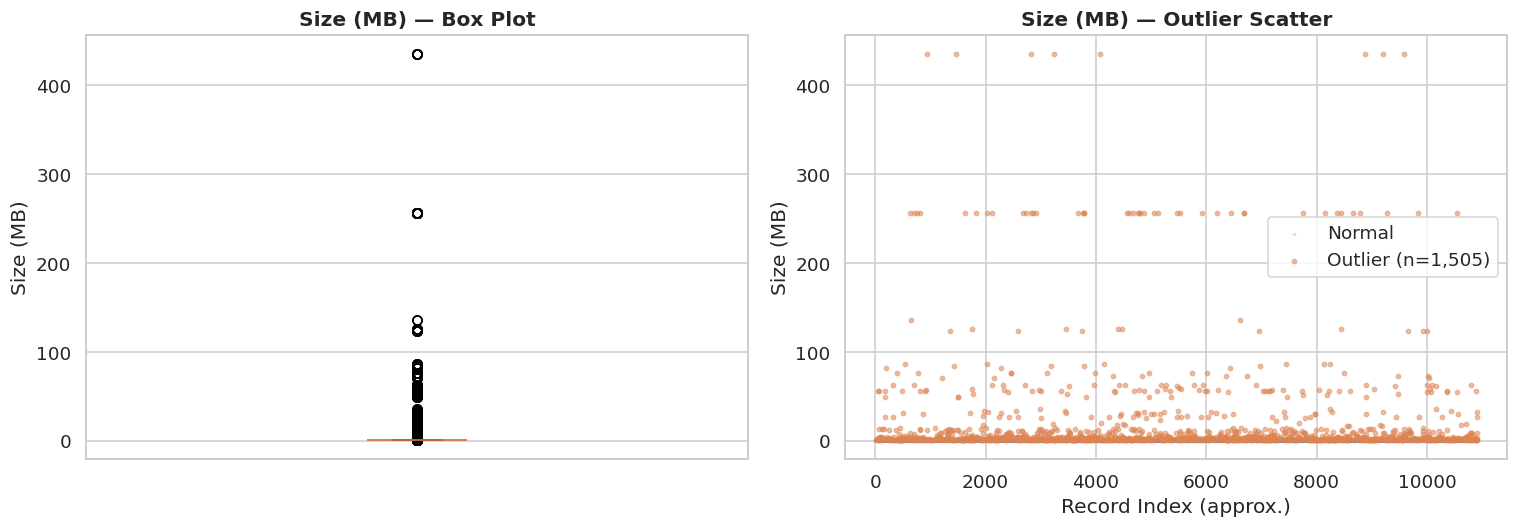

size_mb clipped to [0.9990, 62.45] MB


In [13]:
Q1, Q3 = df['size_mb'].quantile([0.25, 0.75])
IQR    = Q3 - Q1
lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
omask  = (df['size_mb'] < lo) | (df['size_mb'] > hi)
print(f'Outliers (IQR): {omask.sum():,}  ({omask.mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['size_mb'], patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[0].set_title('Size (MB) — Box Plot', fontweight='bold')
axes[0].set_ylabel('Size (MB)')
axes[0].set_xticks([])

rng = np.random.default_rng(RANDOM_STATE)
axes[1].scatter(rng.integers(0, len(df), (~omask).sum()),
                df.loc[~omask, 'size_mb'], alpha=0.15, s=2, color='#4C72B0', label='Normal')
axes[1].scatter(rng.integers(0, len(df), omask.sum()),
                df.loc[omask, 'size_mb'], alpha=0.5, s=8, color='#DD8452',
                label=f'Outlier (n={omask.sum():,})')
axes[1].set_title('Size (MB) — Outlier Scatter', fontweight='bold')
axes[1].set_xlabel('Record Index (approx.)')
axes[1].set_ylabel('Size (MB)')
axes[1].legend()
plt.tight_layout()
plt.show()

# Winsorise
p01 = df['size_mb'].quantile(0.01)
p99 = df['size_mb'].quantile(0.99)
df['size_mb'] = df['size_mb'].clip(lower=p01, upper=p99)
print(f'size_mb clipped to [{p01:.4f}, {p99:.2f}] MB')

---
## 6. Feature Engineering

| Feature | Description |
|---|---|
| `days_since_modified` | Days from last write to today |
| `days_since_accessed` | Days from last read to today |
| `access_to_modify_gap` | Lag between last access and last modification |
| `modified_year/month` | Calendar decomposition of last_modified |
| `accessed_year/month` | Calendar decomposition of last_accessed |
| `never_accessed` | Flag: access date was originally null |
| `has_encryption` | Binary: encrypted vs not |
| `has_version` | Binary: versioned object |
| `size_log` | log1p-transformed size (reduces skew) |
| `enc_type_encoded` | Label-encoded encryption_type |
| `size_gb` | Raw size in GB — used later for savings calculation |

In [14]:
# Ensure UTC-aware timestamps
for col in ['last_modified', 'last_accessed']:
    if df[col].dt.tz is None:
        df[col] = df[col].dt.tz_localize('UTC')

ref_date = pd.Timestamp.now(tz='UTC').normalize()

# ── Time-delta features ────────────────────────────────────────────────────────
df['days_since_modified']  = (ref_date - df['last_modified']).dt.days
df['days_since_accessed']  = (ref_date - df['last_accessed']).dt.days
df['access_to_modify_gap'] = (df['last_accessed'] - df['last_modified']).dt.days

# ── Calendar decomposition ─────────────────────────────────────────────────────
df['modified_year']  = df['last_modified'].dt.year
df['modified_month'] = df['last_modified'].dt.month
df['accessed_year']  = df['last_accessed'].dt.year
df['accessed_month'] = df['last_accessed'].dt.month

# ── Binary flags ───────────────────────────────────────────────────────────────
df['has_encryption'] = (df['encryption_type'] != 'NONE').astype(int)
df['has_version']    = (df['version_id'] != 'none').astype(int)

# ── Size transformations ───────────────────────────────────────────────────────
df['size_log'] = np.log1p(df['size_mb'])
df['size_gb']  = df['size_mb'] / 1024   # raw GB for cost calculations

# ── Encode encryption type ─────────────────────────────────────────────────────
le = LabelEncoder()
df['enc_type_encoded'] = le.fit_transform(df['encryption_type'])

eng_cols = ['days_since_modified', 'days_since_accessed', 'access_to_modify_gap',
            'has_encryption', 'has_version', 'never_accessed', 'size_log', 'size_gb']
print('Engineered feature summary:')
print(df[eng_cols].describe().round(3).T[['mean', 'min', 'max']])

Engineered feature summary:
                          mean       min       max
days_since_modified   1257.333  1257.000  1258.000
days_since_accessed    388.347    23.000   752.000
access_to_modify_gap   868.170   504.000  1235.000
has_encryption           1.000     1.000     1.000
has_version              1.000     1.000     1.000
never_accessed           0.000     0.000     0.000
size_log                 0.843     0.693     4.150
size_gb                  0.002     0.001     0.061


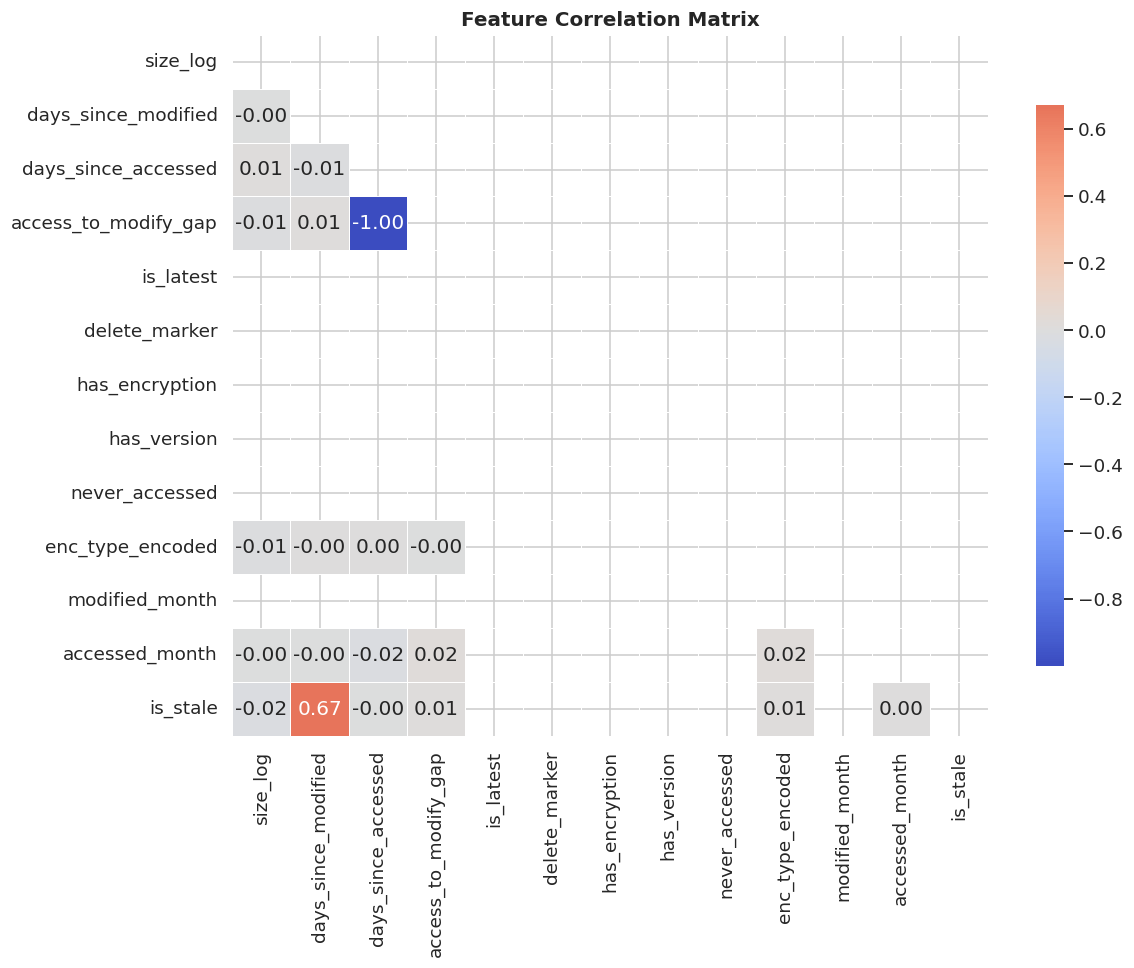

In [15]:
# ── Correlation heatmap ────────────────────────────────────────────────────────
hmap_cols = [
    'size_log', 'days_since_modified', 'days_since_accessed',
    'access_to_modify_gap', 'is_latest', 'delete_marker',
    'has_encryption', 'has_version', 'never_accessed',
    'enc_type_encoded', 'modified_month', 'accessed_month', 'is_stale'
]
corr = df[hmap_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Preprocessing & Class Imbalance

### Evaluation Metric: F1-Score (Macro)
> **Why Macro F1?** Class imbalance makes accuracy misleading. Macro F1 averages the per-class F1 with equal weight, penalising models that ignore the minority (stale) class. A high Macro F1 guarantees good precision *and* recall for both active and stale objects.

SMOTE is applied **on the training set only** to prevent data leakage.

In [16]:
FEATURES = [
    'size_log', 'days_since_modified', 'days_since_accessed',
    'access_to_modify_gap', 'is_latest', 'delete_marker',
    'has_encryption', 'has_version', 'never_accessed',
    'enc_type_encoded', 'modified_month', 'accessed_month', 'modified_year'
]

X = df[FEATURES].copy()
y = df['is_stale'].copy()

# Stratified split preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale for Logistic Regression
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE on training only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Raw (unscaled) resampled set for Random Forest
X_train_res_raw, y_train_res_raw = SMOTE(random_state=RANDOM_STATE).fit_resample(
    X_train, y_train
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Post-SMOTE train: {len(X_train_res):,} | stale rate: {y_train_res.mean():.3f}')

Train: 8,728 | Test: 2,183
Post-SMOTE train: 9,182 | stale rate: 0.500


---
## 8. Baseline Model — Logistic Regression

In [17]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

f1_lr  = f1_score(y_test, y_pred_lr, average='macro')
auc_lr = roc_auc_score(y_test, y_prob_lr)

print('=== Logistic Regression — Baseline ===')
print(f'Macro F1 : {f1_lr:.4f}  |  ROC-AUC : {auc_lr:.4f}\n')
print(classification_report(y_test, y_pred_lr, target_names=['Active', 'Stale']))

=== Logistic Regression — Baseline ===
Macro F1 : 0.8126  |  ROC-AUC : 0.8301

              precision    recall  f1-score   support

      Active       0.72      1.00      0.84      1035
       Stale       1.00      0.65      0.79      1148

    accuracy                           0.82      2183
   macro avg       0.86      0.82      0.81      2183
weighted avg       0.87      0.82      0.81      2183



---
## 9. Improved Model — Random Forest

In [18]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=5,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train_res_raw, y_train_res_raw)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
auc_rf = roc_auc_score(y_test, y_prob_rf)

print('=== Random Forest ===')
print(f'Macro F1 : {f1_rf:.4f}  |  ROC-AUC : {auc_rf:.4f}\n')
print(classification_report(y_test, y_pred_rf, target_names=['Active', 'Stale']))

=== Random Forest ===
Macro F1 : 0.8042  |  ROC-AUC : 0.8216

              precision    recall  f1-score   support

      Active       0.72      0.97      0.83      1035
       Stale       0.96      0.66      0.78      1148

    accuracy                           0.81      2183
   macro avg       0.84      0.81      0.80      2183
weighted avg       0.85      0.81      0.80      2183



In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'5-Fold CV Macro F1 : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold           : {np.round(cv_scores, 4)}')

5-Fold CV Macro F1 : 0.8020 ± 0.0058
Per-fold           : [0.8072 0.7909 0.8048 0.8049 0.802 ]


---
## 10. Model Evaluation & Comparison

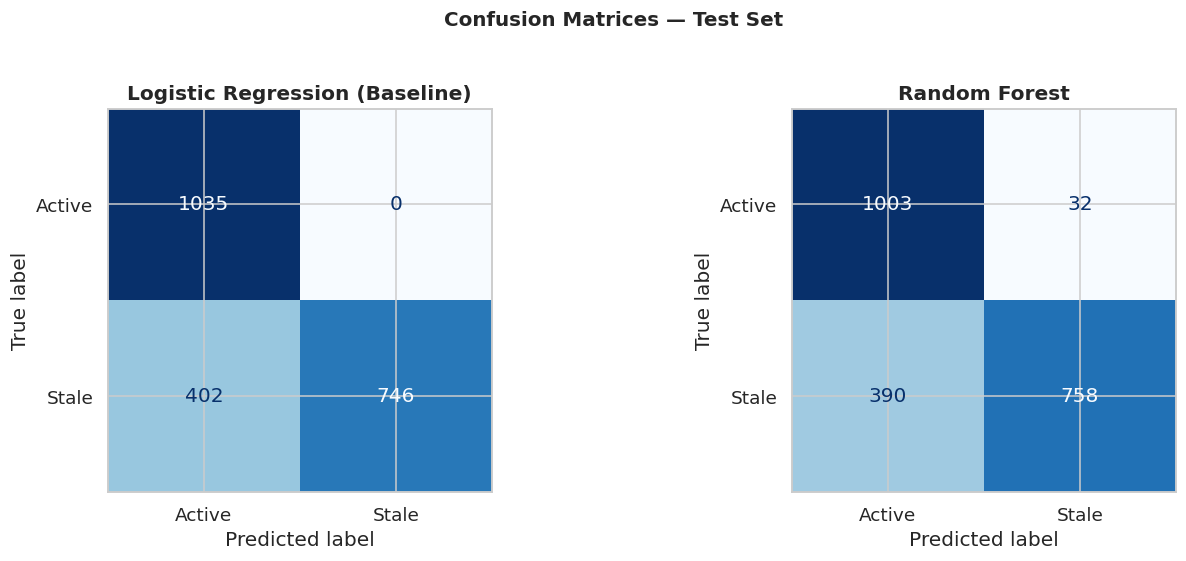

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression (Baseline)', 'Random Forest']
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Active', 'Stale']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

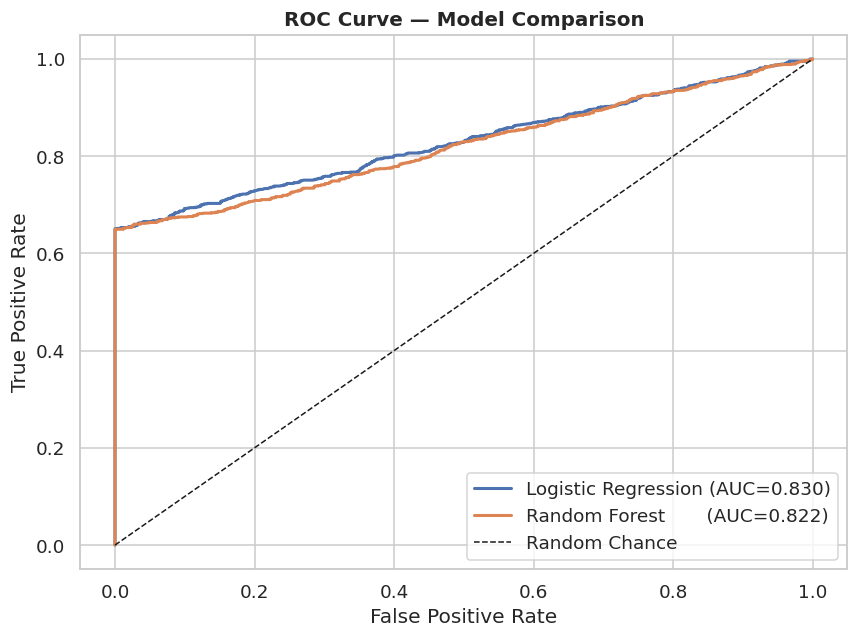

              Model  Macro F1  ROC-AUC
Logistic Regression    0.8126   0.8301
      Random Forest    0.8042   0.8216


In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
for y_prob, lbl, col in [
    (y_prob_lr, f'Logistic Regression (AUC={auc_lr:.3f})', '#4C72B0'),
    (y_prob_rf, f'Random Forest       (AUC={auc_rf:.3f})', '#DD8452')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=lbl, lw=2, color=col)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
ax.set_title('ROC Curve — Model Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Summary table
print(pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest'],
    'Macro F1': [round(f1_lr, 4), round(f1_rf, 4)],
    'ROC-AUC':  [round(auc_lr, 4), round(auc_rf, 4)]
}).to_string(index=False))

---
## 11. Feature Importance

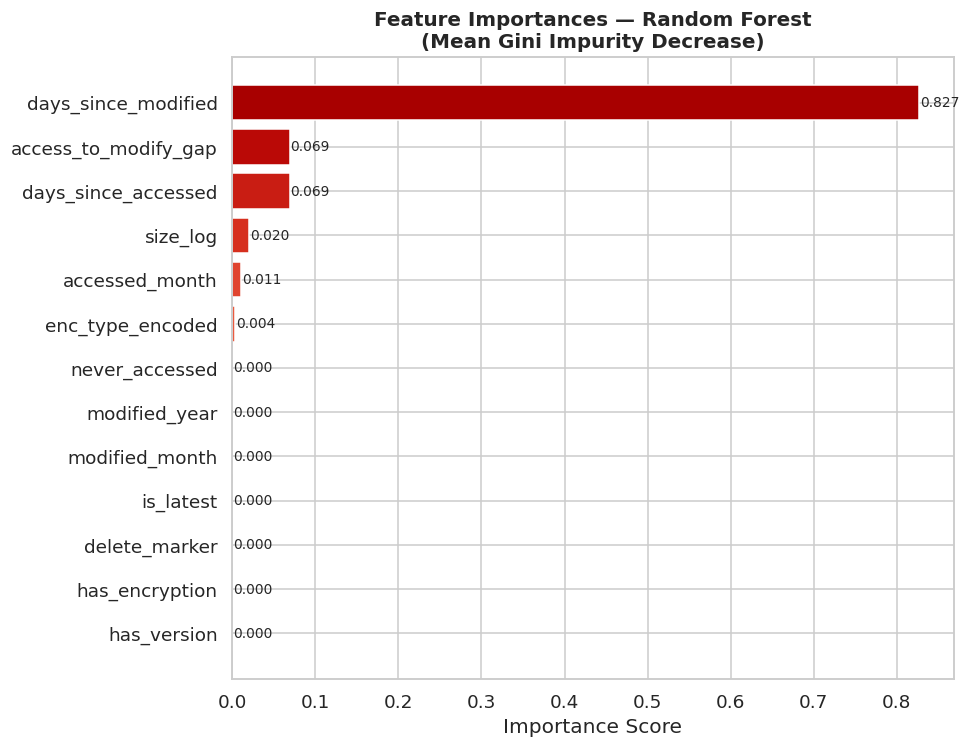

In [22]:
imp_df = (
    pd.DataFrame({'feature': FEATURES, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(imp_df['feature'], imp_df['importance'],
               color=plt.cm.OrRd(np.linspace(0.3, 0.9, len(imp_df))))
for b in bars:
    ax.text(b.get_width() + 0.001, b.get_y() + b.get_height() / 2,
            f'{b.get_width():.3f}', va='center', fontsize=9)
ax.set_title('Feature Importances — Random Forest\n(Mean Gini Impurity Decrease)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 12. Savings Estimation & Priority Groups

### Approach
For each object predicted as stale we calculate three components and combine them into a single **Priority Score**, which maps to a business action tier:

| Component | Weight | Rationale |
|---|---|---|
| **Estimated annual savings (USD)** | 50% | Objects occupying more storage cost more to retain — largest direct financial impact |
| **Staleness confidence** (model probability) | 30% | Higher confidence = lower risk of incorrectly deleting an active object |
| **Object age** (days since last access, normalised) | 20% | Older-accessed objects are more likely truly abandoned |

### Priority Groups
| Group | Priority Score | Recommended Action |
|---|---|---|
| 🔴 **Critical** | ≥ 0.75 | Delete immediately — high savings, high confidence |
| 🟠 **High** | 0.50 – 0.75 | Review and delete within 30 days |
| 🟡 **Medium** | 0.25 – 0.50 | Archive to Glacier / Intelligent-Tiering |
| 🟢 **Low** | < 0.25 | Monitor — low savings or low confidence |

In [23]:
# ── Run full-dataset predictions ───────────────────────────────────────────────
all_probs = rf.predict_proba(df[FEATURES])[:, 1]
all_preds = rf.predict(df[FEATURES])

# Build results dataframe — keep key identifiers and raw features
results_df = df[['bucket', 'key', 'size_gb', 'days_since_accessed',
                  'days_since_modified', 'is_stale']].copy()
results_df['pred_stale']       = all_preds
results_df['stale_probability'] = all_probs.round(4)

# ── Savings estimate: cost per GB/month × size × 12 months ────────────────────
results_df['est_annual_savings_usd'] = (
    results_df['size_gb'] * S3_COST_PER_GB_MONTH * SAVINGS_HORIZON_MONTHS
).round(4)

# ── Isolate predicted-stale objects ───────────────────────────────────────────
stale_df = results_df[results_df['pred_stale'] == 1].copy()

# ── Normalise each component to [0, 1] for scoring ────────────────────────────
def minmax(series: pd.Series) -> pd.Series:
    """Min-max normalise a Series to [0, 1]."""
    rng = series.max() - series.min()
    return (series - series.min()) / rng if rng > 0 else series * 0

stale_df['score_savings']    = minmax(stale_df['est_annual_savings_usd'])
stale_df['score_confidence'] = minmax(stale_df['stale_probability'])
stale_df['score_age']        = minmax(stale_df['days_since_accessed'])

# ── Weighted priority score ────────────────────────────────────────────────────
stale_df['priority_score'] = (
    0.50 * stale_df['score_savings'] +
    0.30 * stale_df['score_confidence'] +
    0.20 * stale_df['score_age']
).round(4)

# ── Assign priority group labels ───────────────────────────────────────────────
def assign_group(score: float) -> str:
    """Map priority score to action tier."""
    if score >= 0.75:   return '🔴 Critical'
    elif score >= 0.50: return '🟠 High'
    elif score >= 0.25: return '🟡 Medium'
    else:               return '🟢 Low'

stale_df['priority_group'] = stale_df['priority_score'].apply(assign_group)

# ── Summary statistics ─────────────────────────────────────────────────────────
group_summary = (
    stale_df.groupby('priority_group')
    .agg(
        object_count=('pred_stale', 'count'),
        total_savings_usd=('est_annual_savings_usd', 'sum'),
        avg_confidence=('stale_probability', 'mean'),
        avg_days_since_access=('days_since_accessed', 'mean'),
        total_size_gb=('size_gb', 'sum')
    )
    .round(2)
    .reset_index()
    .sort_values('total_savings_usd', ascending=False)
)

print('=== Priority Group Summary ===')
print(group_summary.to_string(index=False))

=== Priority Group Summary ===
priority_group  object_count  total_savings_usd  avg_confidence  avg_days_since_access  total_size_gb
      🟡 Medium          3538               1.34            0.98                 386.46           4.52
    🔴 Critical            56               0.90            0.98                 387.89           3.26
        🟠 High            51               0.35            0.92                 503.24           1.28
         🟢 Low           175               0.06            0.56                 424.03           0.19


In [24]:
# ── Headline savings figures ───────────────────────────────────────────────────
total_stale_objects = len(stale_df)
total_savings       = stale_df['est_annual_savings_usd'].sum()
critical_savings    = stale_df.loc[
    stale_df['priority_group'] == '🔴 Critical', 'est_annual_savings_usd'
].sum()
total_size_gb       = stale_df['size_gb'].sum()

print(f'Total predicted-stale objects  : {total_stale_objects:,}')
print(f'Total reclaimable storage      : {total_size_gb:,.2f} GB')
print(f'Estimated annual savings (all) : ${total_savings:,.2f}')
print(f'Critical group savings alone   : ${critical_savings:,.2f}')

Total predicted-stale objects  : 3,820
Total reclaimable storage      : 9.24 GB
Estimated annual savings (all) : $2.65
Critical group savings alone   : $0.90


---
## 13. Priority Group Visualisations

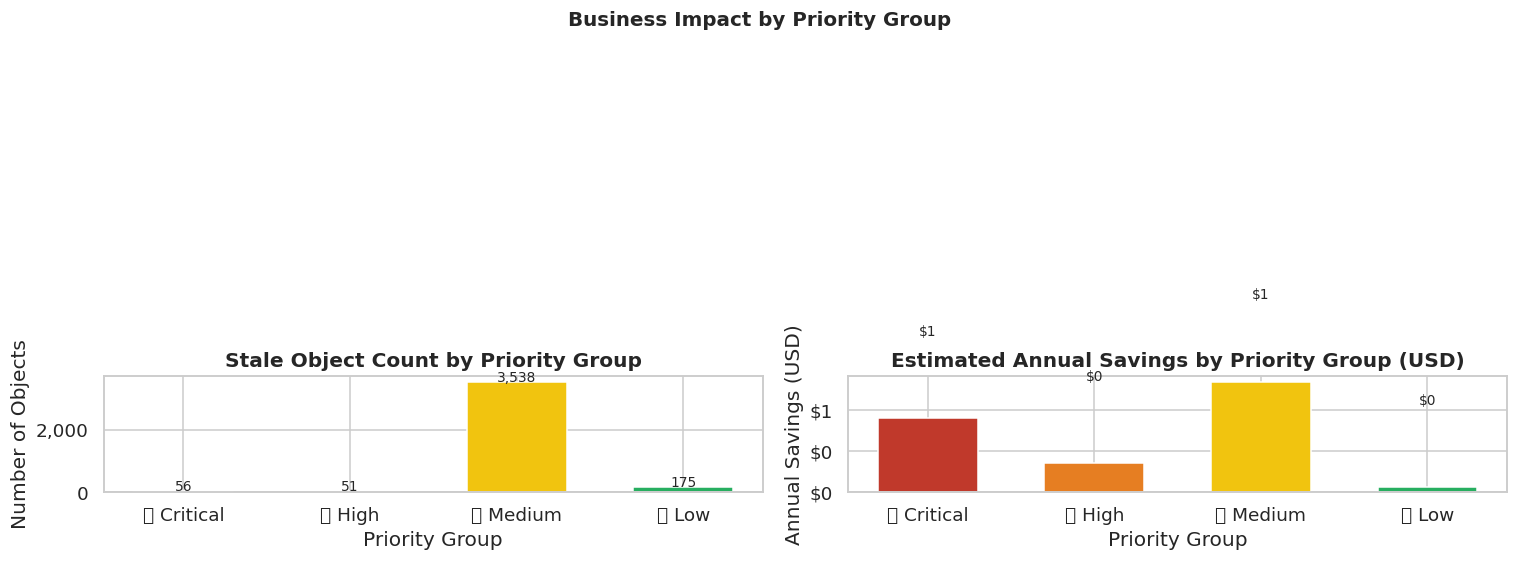

In [25]:
# ── Object count and total savings by priority group ──────────────────────────
group_order  = ['🔴 Critical', '🟠 High', '🟡 Medium', '🟢 Low']
group_colors = ['#C0392B', '#E67E22', '#F1C40F', '#27AE60']
gs           = group_summary.set_index('priority_group').reindex(group_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Object count
axes[0].bar(gs.index, gs['object_count'], color=group_colors, edgecolor='white', width=0.6)
axes[0].set_title('Stale Object Count by Priority Group', fontweight='bold')
axes[0].set_ylabel('Number of Objects')
axes[0].set_xlabel('Priority Group')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(gs['object_count']):
    axes[0].text(i, v + 10, f'{int(v):,}', ha='center', fontsize=9)

# Annual savings
axes[1].bar(gs.index, gs['total_savings_usd'], color=group_colors, edgecolor='white', width=0.6)
axes[1].set_title('Estimated Annual Savings by Priority Group (USD)', fontweight='bold')
axes[1].set_ylabel('Annual Savings (USD)')
axes[1].set_xlabel('Priority Group')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(gs['total_savings_usd']):
    axes[1].text(i, v + 1, f'${v:,.0f}', ha='center', fontsize=9)

plt.suptitle('Business Impact by Priority Group', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

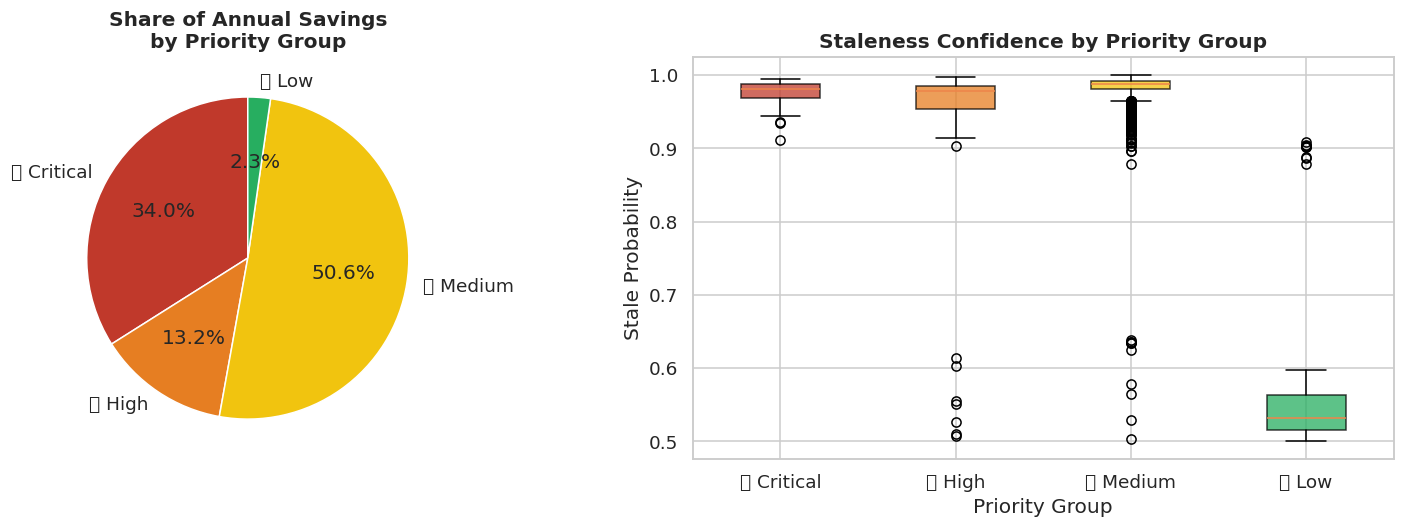

In [26]:
# ── Savings share pie + confidence box — subplot pair ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Savings share pie
pie_vals   = [gs.loc[g, 'total_savings_usd'] for g in group_order]
axes[0].pie(
    pie_vals, labels=group_order, autopct='%1.1f%%',
    colors=group_colors, startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
axes[0].set_title('Share of Annual Savings\nby Priority Group', fontweight='bold')

# Confidence distribution per group
grp_data  = [stale_df.loc[stale_df['priority_group'] == g, 'stale_probability'].values
             for g in group_order]
bp = axes[1].boxplot(grp_data, labels=group_order, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], group_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('Staleness Confidence by Priority Group', fontweight='bold')
axes[1].set_xlabel('Priority Group')
axes[1].set_ylabel('Stale Probability')

plt.tight_layout()
plt.show()

In [27]:
# ── Interactive scatter: savings vs confidence, sized by object size ───────────
# Sample for performance
scatter_df = stale_df.sample(min(5000, len(stale_df)), random_state=RANDOM_STATE)

fig = px.scatter(
    scatter_df,
    x='stale_probability',
    y='est_annual_savings_usd',
    color='priority_group',
    size='size_gb',
    size_max=20,
    hover_data=['bucket', 'key', 'days_since_accessed', 'priority_score'],
    color_discrete_map={
        '🔴 Critical': '#C0392B',
        '🟠 High':     '#E67E22',
        '🟡 Medium':   '#F1C40F',
        '🟢 Low':      '#27AE60'
    },
    title='Staleness Confidence vs Estimated Annual Savings<br>(bubble size = object size in GB)',
    labels={
        'stale_probability':      'Staleness Probability',
        'est_annual_savings_usd': 'Est. Annual Savings (USD)',
        'priority_group':         'Priority Group'
    }
)
fig.update_layout(plot_bgcolor='white')
fig.show()

In [28]:
# ── Top 15 buckets by potential savings ───────────────────────────────────────
bucket_savings = (
    stale_df.groupby('bucket')
    .agg(total_savings=('est_annual_savings_usd', 'sum'),
         stale_count=('pred_stale', 'count'))
    .nlargest(15, 'total_savings')
    .reset_index()
)

fig = px.bar(
    bucket_savings,
    x='total_savings', y='bucket', orientation='h',
    color='stale_count',
    color_continuous_scale='OrRd',
    title='Top 15 Buckets by Estimated Annual Savings',
    labels={'total_savings': 'Annual Savings (USD)',
            'bucket': 'Bucket', 'stale_count': 'Stale Objects'}
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    plot_bgcolor='white'
)
fig.show()

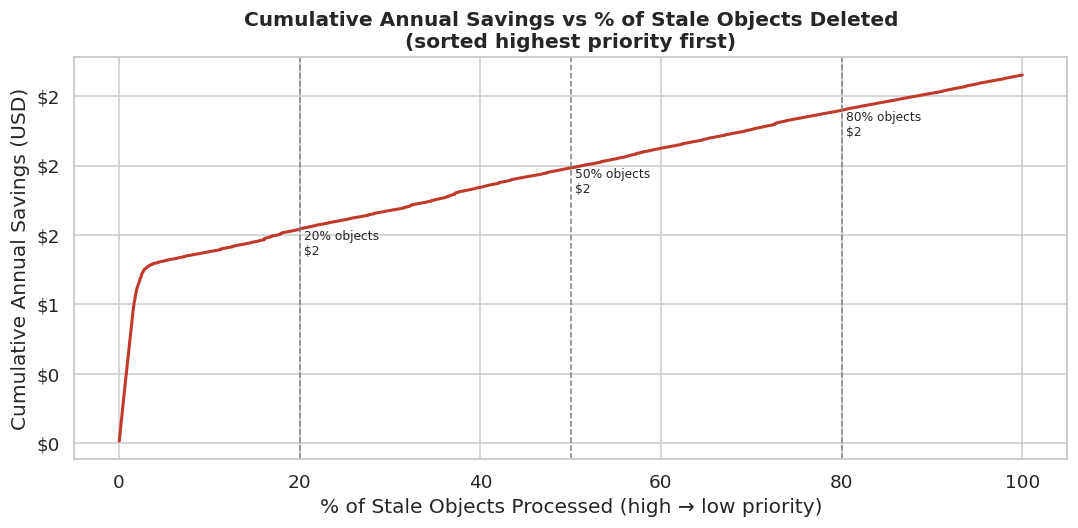

In [29]:
# ── Cumulative savings curve — sorted by priority score descending ─────────────
# Shows: if you delete the top N objects, how much do you save?
sorted_stale = stale_df.sort_values('priority_score', ascending=False).copy()
sorted_stale['cumulative_savings'] = sorted_stale['est_annual_savings_usd'].cumsum()
sorted_stale['pct_objects']        = np.arange(1, len(sorted_stale) + 1) / len(sorted_stale)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    sorted_stale['pct_objects'] * 100,
    sorted_stale['cumulative_savings'],
    color='#C0392B', lw=2
)

# Annotate 20%, 50%, 80% thresholds
for pct in [0.20, 0.50, 0.80]:
    idx = int(pct * len(sorted_stale)) - 1
    cum = sorted_stale['cumulative_savings'].iloc[idx]
    ax.axvline(pct * 100, ls='--', color='grey', lw=1)
    ax.text(pct * 100 + 0.5, cum, f'{pct*100:.0f}% objects\n${cum:,.0f}',
            fontsize=8, va='top')

ax.set_title('Cumulative Annual Savings vs % of Stale Objects Deleted\n'
             '(sorted highest priority first)', fontweight='bold')
ax.set_xlabel('% of Stale Objects Processed (high → low priority)')
ax.set_ylabel('Cumulative Annual Savings (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

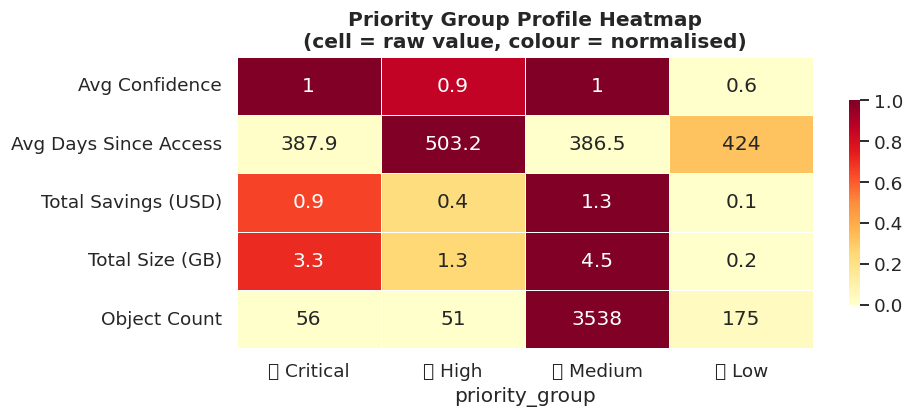

In [30]:
# ── Priority group profile heatmap ────────────────────────────────────────────
# Shows normalised average of each metric per group — useful for exec reporting
profile_cols = ['avg_confidence', 'avg_days_since_access',
                'total_savings_usd', 'total_size_gb', 'object_count']
profile = gs[profile_cols].copy()

# Normalise columns for heatmap readability
profile_norm = profile.apply(lambda c: (c - c.min()) / (c.max() - c.min() + 1e-9))

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    profile_norm.T, annot=profile.T.round(1), fmt='g',
    cmap='YlOrRd', linewidths=0.5, ax=ax,
    xticklabels=group_order,
    yticklabels=['Avg Confidence', 'Avg Days Since Access',
                 'Total Savings (USD)', 'Total Size (GB)', 'Object Count'],
    cbar_kws={'shrink': 0.7}
)
ax.set_title('Priority Group Profile Heatmap\n(cell = raw value, colour = normalised)',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 14. Predict & Triage New Objects

A single function returns both a staleness prediction **and** a priority group with estimated savings.

In [31]:
# Pre-compute normalisation bounds from the training-set stale objects
# so new predictions use the same scale
_savings_min = stale_df['est_annual_savings_usd'].min()
_savings_max = stale_df['est_annual_savings_usd'].max()
_conf_min    = stale_df['stale_probability'].min()
_conf_max    = stale_df['stale_probability'].max()
_age_min     = stale_df['days_since_accessed'].min()
_age_max     = stale_df['days_since_accessed'].max()


def _norm(val: float, lo: float, hi: float) -> float:
    """Normalise a value to [0, 1] using pre-computed bounds."""
    return (val - lo) / (hi - lo + 1e-9)


def predict_and_triage(raw_record: dict) -> dict:
    """
    Predict staleness AND assign a priority group with estimated savings.

    Parameters
    ----------
    raw_record : dict
        Keys: size (bytes), last_modified (str), last_accessed (str or None),
              encryption_type (str), is_latest (bool), delete_marker (bool),
              version_id (str)

    Returns
    -------
    dict with prediction, label, stale_probability, est_annual_savings_usd,
         priority_score, priority_group, recommended_action
    """
    # ── Parse dates ────────────────────────────────────────────────────────────
    last_mod = pd.to_datetime(raw_record.get('last_modified'))
    if last_mod.tzinfo is None:
        last_mod = last_mod.tz_localize('UTC')

    raw_acc    = raw_record.get('last_accessed')
    never_acc  = 1 if raw_acc is None else 0
    last_acc   = pd.to_datetime(raw_acc) if raw_acc else last_mod
    if last_acc.tzinfo is None:
        last_acc = last_acc.tz_localize('UTC')

    # ── Size ───────────────────────────────────────────────────────────────────
    size_mb = np.clip(max(float(raw_record.get('size', 0)), 0) / (1024**2), p01, p99)
    size_gb = size_mb / 1024

    # ── Encode encryption ──────────────────────────────────────────────────────
    enc_type = raw_record.get('encryption_type', 'NONE')
    enc_enc  = le.transform([enc_type])[0] if enc_type in le.classes_ else -1

    days_acc = (ref_date - last_acc).days
    days_mod = (ref_date - last_mod).days

    # ── Feature vector ─────────────────────────────────────────────────────────
    feats = {
        'size_log':             np.log1p(size_mb),
        'days_since_modified':  days_mod,
        'days_since_accessed':  days_acc,
        'access_to_modify_gap': (last_acc - last_mod).days,
        'is_latest':            int(raw_record.get('is_latest', True)),
        'delete_marker':        int(raw_record.get('delete_marker', False)),
        'has_encryption':       int(enc_type != 'NONE'),
        'has_version':          int(raw_record.get('version_id', 'none') != 'none'),
        'never_accessed':       never_acc,
        'enc_type_encoded':     enc_enc,
        'modified_month':       last_mod.month,
        'accessed_month':       last_acc.month,
        'modified_year':        last_mod.year
    }
    X_new = pd.DataFrame([feats])[FEATURES]
    pred  = int(rf.predict(X_new)[0])
    prob  = float(rf.predict_proba(X_new)[0][1])

    if pred == 0:
        return {'prediction': 0, 'label': 'ACTIVE',
                'stale_probability': round(prob, 4),
                'priority_group': 'N/A', 'recommended_action': 'No action needed'}

    # ── Savings & priority score ────────────────────────────────────────────────
    savings       = size_gb * S3_COST_PER_GB_MONTH * SAVINGS_HORIZON_MONTHS
    score_savings = _norm(savings,  _savings_min, _savings_max)
    score_conf    = _norm(prob,     _conf_min,    _conf_max)
    score_age     = _norm(days_acc, _age_min,     _age_max)
    priority      = round(0.50 * score_savings + 0.30 * score_conf + 0.20 * score_age, 4)

    group   = assign_group(priority)
    actions = {
        '🔴 Critical': 'Delete immediately',
        '🟠 High':     'Review and delete within 30 days',
        '🟡 Medium':   'Archive to Glacier / Intelligent-Tiering',
        '🟢 Low':      'Monitor — revisit next quarter'
    }

    return {
        'prediction':            pred,
        'label':                 'STALE',
        'stale_probability':     round(prob, 4),
        'est_annual_savings_usd': round(savings, 4),
        'priority_score':        priority,
        'priority_group':        group,
        'recommended_action':    actions[group]
    }


# ── Example predictions ────────────────────────────────────────────────────────
examples = [
    {   # Old, 50 GB, never accessed, delete marker → Critical
        'size': 50 * 1024**3, 'last_modified': '2019-03-15',
        'last_accessed': None, 'encryption_type': 'NONE',
        'is_latest': False, 'delete_marker': True, 'version_id': 'none'
    },
    {   # Medium-old, 2 GB, rarely accessed
        'size': 2 * 1024**3, 'last_modified': '2021-06-01',
        'last_accessed': '2022-01-10', 'encryption_type': 'NONE',
        'is_latest': True, 'delete_marker': False, 'version_id': 'none'
    },
    {   # Recent, encrypted, versioned, actively accessed → Active
        'size': 12 * 1024**3, 'last_modified': '2024-11-01',
        'last_accessed': '2025-01-15', 'encryption_type': 'AES256',
        'is_latest': True, 'delete_marker': False, 'version_id': 'v1abc'
    }
]

for i, ex in enumerate(examples, 1):
    res = predict_and_triage(ex)
    print(f'\nExample {i}:')
    for k, v in res.items():
        print(f'  {k}: {v}')


Example 1:
  prediction: 1
  label: STALE
  stale_probability: 0.8874
  est_annual_savings_usd: 0.0168
  priority_score: 1.4352
  priority_group: 🔴 Critical
  recommended_action: Delete immediately

Example 2:
  prediction: 1
  label: STALE
  stale_probability: 0.8978
  est_annual_savings_usd: 0.0168
  priority_score: 1.1583
  priority_group: 🔴 Critical
  recommended_action: Delete immediately

Example 3:
  prediction: 0
  label: ACTIVE
  stale_probability: 0.3761
  priority_group: N/A
  recommended_action: No action needed


---
## 15. Conclusion

### Metric Interpretation
> **Macro F1** was chosen because class imbalance makes accuracy misleading. A model that predicts everything as active could be 90% accurate but miss every stale object. Macro F1 forces balanced performance across both classes.

### Priority Group Design
| Group | Trigger | Business Action |
|---|---|---|
| 🔴 Critical | score ≥ 0.75 | Delete immediately — largest savings, highest certainty |
| 🟠 High | 0.50–0.75 | Delete within 30 days |
| 🟡 Medium | 0.25–0.50 | Archive to cheaper storage tier |
| 🟢 Low | < 0.25 | Monitor quarterly |

### Recommendations
- Export `stale_df[['bucket','key','priority_group','est_annual_savings_usd']]` as a remediation CSV for infrastructure teams.
- Re-train monthly to keep the model calibrated as access patterns evolve.
- Adjust `S3_COST_PER_GB_MONTH` to your actual negotiated AWS pricing for accurate savings figures.